In [1]:
import json
import re
from typing import Any, Dict, List

import dvc.api
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from IPython.display import HTML, display
from matplotlib import pyplot as plt

In [2]:
metrics_commits = {
    "CYFRAGOVPL/Llama-PLLuM-8B-instruct": "c9e5cdd13e9dfa0132091f748107d281968f1b6a",
    "speakleash/Bielik-11B-v2.2-Instruct": "3c8b0959adf5a6c89e71e0b9e7fba5f9c104bc78",
    "GPT-4o-mini": "84bd0e7d9e3f57e43d555694e798e6185b494730",
    "PLLUMGraph": "284ac7451a9065057519ed1985fb75df15a772c8",
}

metrics_dicts = {k: dvc.api.metrics_show(rev=sha) for k, sha in metrics_commits.items()}

In [3]:
measuring_strategies = ["Ent_type", "Partial", "Strict", "Exact"]
values = {
    k: [v["total_f1"][s] for s in measuring_strategies]
    for k, v in metrics_dicts.items()
}

In [4]:
def plot_bar_grouped(
    x_labels: List[str], values: Dict[str, List[float]], ax_kwargs: Dict[str, Any] = {}
):
    x = np.arange(len(x_labels))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(layout="constrained")

    for attribute, measurement in values.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3, fmt="%.2f")
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set(**ax_kwargs)
    ax.set_xticks(x + width, x_labels)
    ax.legend(loc="best")

    fig.show()

# 1. Overall F1 scores

PLLUMGraph achieved similar results to Bielik, which looks promising, but also suggests that Bielik has been heavily used.

/tmp/ipykernel_3425923/3429667109.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


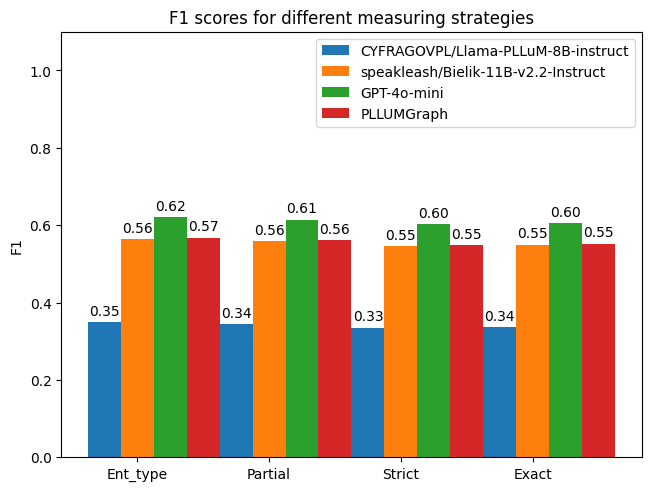

In [5]:
plot_bar_grouped(
    measuring_strategies,
    values,
    ax_kwargs={
        "ylabel": "F1",
        "title": "F1 scores for different measuring strategies",
        "ylim": (0, 1.1),
    },
)

In [6]:
total_found_objects = ["Subjects", "Predicates", "Objects", "Full_triples"]
values = {
    k: [
        v["total_found_strict_or_partial_percent"][s.lower()]
        for s in total_found_objects
    ]
    for k, v in metrics_dicts.items()
}

# 2. Successfuly detected parts of triples

Again - results quite close to Bielik

/tmp/ipykernel_3425923/3429667109.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


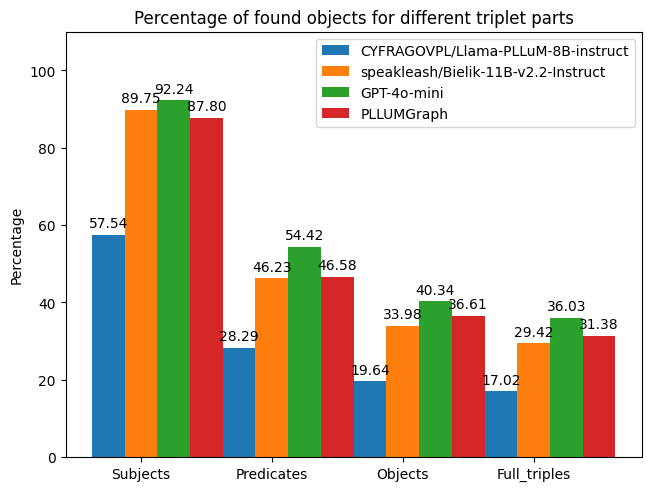

In [7]:
plot_bar_grouped(
    total_found_objects,
    values,
    ax_kwargs={
        "ylabel": "Percentage",
        "title": "Percentage of found objects for different triplet parts",
        "ylim": (0, 110),
    },
)

In [8]:
def get_extracted_relations(commit: str):
    with dvc.api.open("data/edc_baseline/cands.xml", rev=commit) as f:
        cands = f.read()
        # Parse the XML data
        soup = BeautifulSoup(cands, "xml")

        # Extract all gtriple elements
        cands = [gtriple.text for gtriple in soup.find_all("gtriple")]

    with dvc.api.open("data/edc_baseline/refs.xml", rev=commit) as f:
        refs = f.read()
        # Parse the XML data
        soup = BeautifulSoup(refs, "xml")

        # Extract all gtriple elements
        refs = [otriple.text for otriple in soup.find_all("otriple")]

    with dvc.api.open("data/edc_baseline/extracted_relations.json", rev=commit) as f:
        responses = json.loads(f.read())["responses"]

    return dict(cands=cands, refs=refs, responses=responses)


extracted_relations = {
    k: get_extracted_relations(v) for k, v in metrics_commits.items()
}

In [9]:
pattern = r"^.+\s\|\s.+\s\|\s.+$"


def is_valid_triple(triple: str):
    return bool(re.match(pattern, triple))

In [10]:
number_of_invalid_triples = {
    k: sum([not is_valid_triple(triple) for triple in v["cands"]])
    for k, v in extracted_relations.items()
}

In [11]:
number_of_invalid_triples

{'CYFRAGOVPL/Llama-PLLuM-8B-instruct': 6070,
 'speakleash/Bielik-11B-v2.2-Instruct': 601,
 'GPT-4o-mini': 308,
 'PLLUMGraph': 874}

In [12]:
def plot_bar_ungrouped(
    x_labels: List[str],
    values: List[float],
    ax_kwargs: Dict[str, Any] = {},
    xticks_kwargs: Dict[str, Any] = {},
):
    x = np.arange(len(x_labels))  # the label locations
    width = 0.25  # the width of the bars

    fig, ax = plt.subplots()

    rects = ax.bar(x, values, width)
    ax.bar_label(rects, padding=3, fmt="%.2f")

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set(**ax_kwargs)
    ax.set_xticks(x, x_labels, **xticks_kwargs)

    fig.show()

# 3. Number of invalid triples

Drastic improvement when counting invalid triples, when comparing baseline PLLUM and PLLUMGraph.

/tmp/ipykernel_3425923/3878522688.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


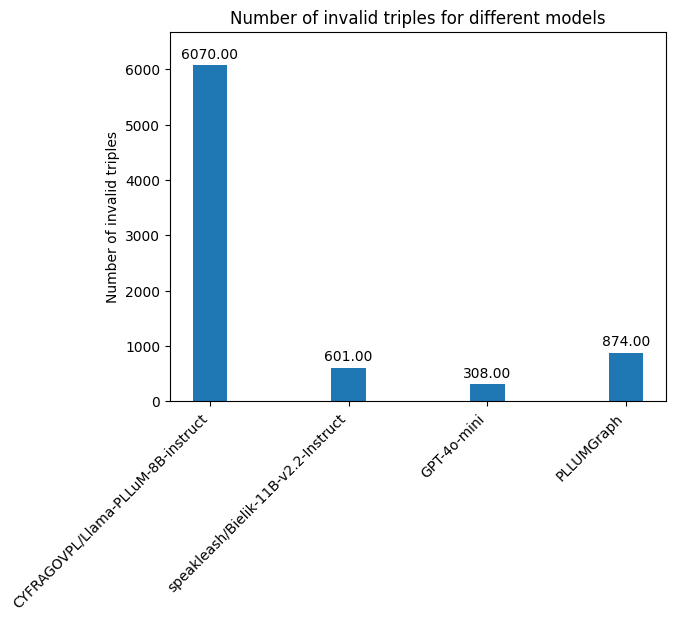

In [13]:
plot_bar_ungrouped(
    list(number_of_invalid_triples.keys()),
    list(number_of_invalid_triples.values()),
    ax_kwargs={
        "ylabel": "Number of invalid triples",
        "title": "Number of invalid triples for different models",
        "ylim": (0, max(number_of_invalid_triples.values()) * 1.1),
    },
    xticks_kwargs={"rotation": 45, "ha": "right"},
)

# 4. Invalid triples - deep dive

Explanation of found errors in 50-element sample of invalid outputs for each model:

1. PLLUM presented following errors when inspecting outputs: too many triples extracted at once (we expect one per text), wrong response format that does not allow parsing (too many/too few brackets, mixing square, curly and ordinary brackets), explicit refusal to answer ('I cannot find any relations', 'There are no triples that can be extracted', 'I do not know how to answer' etc.).

    Sample of 50 invalid responses:
    - 40 refusals (80%)
    - 5 too many triples (10%)
    - 5 wrong format (10%)

    The refusal type of error is unique to PLLUM and did not occur in other models.

2. Bielik presented following errors when inspecting outputs: verbose explanation (unnecessary text showing the thoght process that resulted in an answer, confusing the parser), too many triples (same error as in PLLUM), wrong response format (same error as in PLLUM).

    Sample of 50 invalid responses:
    - 34 too many triples (68%)
    - 8 vervose explanations (16%)
    - 8 wrong formats (16%)

    The verbose explanation type of error is unique to Bielik and did not occur in other models.

3. GPT-4o-mini presented exclusively errors of wrong format type.

All 3 models presented wrong format errors.

In [14]:
def show_invalid_responses(model):
    extracted_relations_pllum = pd.DataFrame(extracted_relations[model])
    extracted_relations_pllum["is_valid"] = extracted_relations_pllum.cands.apply(
        is_valid_triple
    )
    display(
        HTML(
            pd.DataFrame(
                extracted_relations_pllum[
                    extracted_relations_pllum.is_valid == False
                ].responses
            )
            .sample(50)
            .to_html()
        )
    )


show_invalid_responses("CYFRAGOVPL/Llama-PLLuM-8B-instruct")

,responses
13749,Nie ma żadnej relacji między tymi dwoma obiektami.
6879,"[[""Andrea Louise Riseborough"", ""zawód"", ""Aktor""],]"
11042,"Nie ma wystarczających informacji, aby wywnioskować relację."
13427,Nie ma żadnej relacji.
619,"[('Kamil Bednarek', 'zawód', 'Autor tekstów i piosenek'), ('Kamil Bednarek','miejsce urodzenia', 'Brzeg')]"
3002,"[[""Marco Cappato"", ""miejsce urodzenia"", ""Mediolan""], [""Marco Cappato"", ""zawód"", ""Polityk""], [""Marco Cappato"", ""miejsce pracy"", ""Parlament Europejski""]]"
1463,"[[Ambrose Madtha, miejsce urodzenia, Man],"
10430,"Nie ma żadnej relacji, która pasuje do podanego tekstu."
3455,Nie ma żadnej relacji.
9951,"Nie ma relacji, którą można wyciągnąć z tego tekstu."


In [15]:
show_invalid_responses("speakleash/Bielik-11B-v2.2-Instruct")

,responses
5450,"['Rod Fanni', 'zawód', 'Piłkarz']]"
1981,"[['Ulysses', 'lokalizacja', 'Hrabstwo Grant'], ['Ulysses', 'liczba ludności', '6161']]"
16994,"[['Lone Tree', 'lokalizacja','city-data.com']]\n[['Lone Tree', 'liczba ludności', '860 mieszkańców']]\n[['Lone Tree', 'położenie', 'Hrabstwo Clay']]"
11663,"[['Kurt Vonnegut Jr.','miejsce urodzenia', 'Indianapolis']] \n\nUzasadnienie: Zdanie wyraźnie wskazuje, że Kurt Vonnegut Jr. urodził się w Indianapolis. Trójka zawierająca datę urodzenia oraz miejsce urodzenia jest najbardziej bezpośrednim i prawdopodobnym połączeniem tych dwóch obiektów."
108,"[['Death Row Records', 'organizacja ma założyciela', 'Suge Knight']]\n[['Death Row Records', 'organizacja ma założyciela', 'Dr. Dre']]"
2549,"[['Hrabstwo Chautauqua', 'lokalizacja', 'Kansas']]\n[['Hrabstwo Chautauqua','siedziba', 'Sedan']]"
14910,"['Carl Rune Larsson','miejsce urodzenia', 'Sztokholm']]"
6146,"[['Villeneuve-lès-Charnod', 'lokalizacja', 'Francja']]\n[['Villeneuve-lès-Charnod', 'liczba ludności', '77 mieszkańców']]"
16601,"[['Kirchtroisdorf', 'lokalizacja', 'Niemcy']]\n."
12249,"[['Roberts Zīle', 'zawód', 'Ekonomista'], ['Roberts Zīle', 'lider organizacji', 'Sejm'], ['Roberts Zīle', 'lider organizacji', 'Parlament Europejski']]"


In [16]:
show_invalid_responses("GPT-4o-mini")

,responses
10101,"[['Agat', 'liczba ludności', '4917']]]"
6983,"[['Mohammad Beheszti', 'miejsce urodzenia', 'Isfahan']]}"
10017,"[['Cuevas de San Clemente', 'liczba ludności', '56']]\n\n"
7435,"[['Pan', 'typ', 'Bóg']]}"
9628,"[['Angara Airlines', 'siedziba', 'Irkuck']]}"
3457,"[['North Dandalup', 'lokalizacja', 'Australia']]]"
6744,"[['Jean-Jacques Ampère', 'miejsce urodzenia', 'Lyon']]]"
12033,"[['Oak Brook', 'liczba ludności', '7883']]}"
16892,"[['Melandra', 'lokalizacja', 'Cypr']]]"
7321,"[['Pinjarra', 'lokalizacja', 'Australia']]}"


In [38]:
pllumgraph_inv_responses = show_invalid_responses("PLLUMGraph")
pllumgraph_inv_responses

,responses
15531,"[[('Voltaire', 'zawód', 'Muzyk'), ('Aurelio Voltaire Hernández','miejsce urodzenia', 'Hawana'), ('Voltaire','miejsce urodzenia', 'Kuba')],[('Krzysztof Kieślowski', 'autor', 'Przypadek'), ('Magdalena Piekorz', 'autor', 'Pręgi'), ('Wojciech Kuczok', 'aktor', 'Przypadek'), ('Wojciech Kuczok', 'aktor', 'Pręgi')]"
16491,"[[Amanda Somerville-Scharf, miejsce urodzenia, Flushing, Michigan]]"
15751,"[[D.W. Griffith, miejsce urodzenia, LaGrange, Hrabstwo Oldham (Kentucky)]]"
9858,"[[St. Georgen an der Gusen, lokalizacja, Austrii], [Austriacki Urząd Statystyczny, instytucja, Edukacja]]"
16379,"[['Papieskie Kolegium Północnoamerykańskie', 'edukacja', 'Klerycy, księża']]\n[['Papieskie Kolegium Północnoamerykańskie', 'lokalizacja', 'Rzym']]"
5268,"[['Święty Sebastian', 'obraz', 'Tycjan']]\n\n**Wyjaśnienie:**\n\nTrójka przedstawia związek między obrazem ""Święty Sebastian"" a renesansowym malarzem weneckim, Tycjanem. Obraz jest dziełem Tycjana, stworzonym w latach 1570-1572. Relacja ""obraz"" łączy obraz z jego twórcą."
15239,"['Prostokąt', 'typ', 'Czworokąt']]"
3611,"[['Diecezja Mayagüez','miejsce urodzenia', 'Mayagüez']]\n\n[['Diecezja Mayagüez', 'typ', 'Rzymskokatolicka diecezja']]\n\n[['Diecezja Mayagüez','siedziba', 'Mayagüez']]\n\n[['Diecezja Mayagüez', 'z kraju', 'Portoryko']]\n\n[['Diecezja Mayagüez', 'członek', 'Kościół katolicki']]\n\n[['Diecezja Mayagüez', 'organizacja ma siedzibę w', 'Mayagüez']]\n\n[['Diecezja Mayagüez', 'organizacja', 'Kościół katolicki']]\n\n[['Diecezja Mayagüez', 'lokalizacja', 'Mayagüez']]\n\n[['Diecezja Mayagüez', 'typ organizacji', 'Diecezja']]\n\n[['Diecezja Mayagüez','siedziba organizacji', 'Mayagüez']]\n\n[['Diecezja Mayagüez', 'z kraju', 'Portoryko']]\n\n[['Diecezja Mayagüez', 'członek', 'Kościół katolicki']]"
6287,"[[Fayette', 'lokalizacja', 'Decatur'], ['Gmina Fayette', 'Liczba ludności', '185'], ['Gmina Fayette', 'Powierzchnia', '59,99 km²']]"
7048,"[[Hideo Kojima, miejsce urodzenia, Setagaya, Tokio]]"


In [18]:
import pickle


with dvc.api.open(
    "data/edc_baseline/graph_states.pkl", rev=metrics_commits["PLLUMGraph"], mode="rb"
) as f:
    graph_states = pickle.load(f)

len(graph_states)

17171

<Axes: >

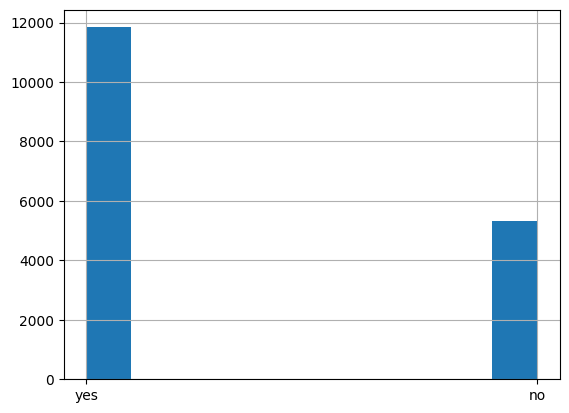

In [19]:
refusals_series = pd.Series(
    map(lambda x: "yes" if x["did_attempt_to_answer"] else "no", graph_states)
)
refusals_series.hist()

In [20]:
refusals_counts = refusals_series.value_counts(normalize=True) * 100
refusals_counts

yes    68.953468
no     31.046532
Name: proportion, dtype: float64

# 5. Conclusions for this part

TBA